## CRIME DATA ANALYSIS

## Business Context

Understanding crime patterns is essential for identifying risk factors, improving public safety strategies, and supporting decision-making in law enforcement and policy design.

## Objective

Analyze the dataset to identify patterns in crime characteristics such as demographics, victim-offender relationships, and incident types.

## Key Questions
What are the most common types of incidents?
What demographic patterns exist between victims and offenders?
Are there inconsistencies or data quality issues that could affect analysis?

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
df=pd.read_csv("crime_data.csv")
df.shape

(6638, 12)

Insight: The dataset contains 6,638 rows and 12 columns.

## Initial Exploration
We review the structure, data types, and summary statistics.

In [3]:
df.info()
df.head(10)
df.describe()
df.describe(include="object")
#outliers 124

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6638 entries, 0 to 6637
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Disposition          6638 non-null   object 
 1   OffenderStatus       6638 non-null   object 
 2   Offender_Race        6638 non-null   object 
 3   Offender_Gender      6638 non-null   object 
 4   Offender_Age         6638 non-null   float64
 5   PersonType           6638 non-null   object 
 6   Victim_Race          6638 non-null   object 
 7   Victim_Gender        6638 non-null   object 
 8   Victim_Age           6638 non-null   float64
 9   Victim_Fatal_Status  6638 non-null   object 
 10  Report Type          6638 non-null   object 
 11  Category             6638 non-null   object 
dtypes: float64(2), object(10)
memory usage: 622.4+ KB


,Disposition,OffenderStatus,Offender_Race,Offender_Gender,PersonType,Victim_Race,Victim_Gender,Victim_Fatal_Status,Report Type,Category
count,6638,6638,6638,6638,6638,6638,6638,6638,6638,6638
unique,2,1,6,2,3,6,3,2,2,6
top,CLOSED,ARRESTED,BLACK,MALE,VICTIM,BLACK,FEMALE,Non-fatal,Incident Report,Violence
freq,6256,6638,5453,4987,6632,4394,3991,6614,3459,3489


Insight:

- The dataset is mostly composed of categorical variables
- Only two numerical variables are present (Offender_Age, Victim_Age)
- No immediate structural issues are observed

## Column Name Cleaning

We standardize column names for consistency and easier manipulation.

In [4]:
df.columns=(df.columns.str.strip().str.replace(" ","_"))

Insight: Clean column names reduce errors in analysis and improve readability.

## Missing Values Analysis

We evaluate the presence of null values and their potential impact.

In [5]:
df.isna().mean()

Disposition            0.0
OffenderStatus         0.0
Offender_Race          0.0
Offender_Gender        0.0
Offender_Age           0.0
PersonType             0.0
Victim_Race            0.0
Victim_Gender          0.0
Victim_Age             0.0
Victim_Fatal_Status    0.0
Report_Type            0.0
Category               0.0
dtype: float64

Insight:
There are no missing values in the dataset, which simplifies preprocessing and reduces the need for imputation.

## Categorical Analysis

We analyze categorical variables to understand dataset composition.

In [6]:
categorical= df.select_dtypes(include="object")
categorical.apply(lambda x:x.unique())
categorical.apply(lambda x:x.nunique())

Disposition            2
OffenderStatus         1
Offender_Race          6
Offender_Gender        2
PersonType             3
Victim_Race            6
Victim_Gender          3
Victim_Fatal_Status    2
Report_Type            2
Category               6
dtype: int64

Insight:

- Low cardinality across categorical variables
- Suitable for grouping, aggregation, and segmentation analysis
- Indicates structured and standardized data collection

## Duplicate Analysis

We verify if duplicate records exist.

In [7]:
df.duplicated().sum()
df.duplicated().mean()

np.float64(0.292859294968364)

Insight:
A significant number of duplicates were detected (~30% of the dataset).

This suggests:

- Possible data entry or export issues
- Risk of bias in analysis if not handled

We inspect duplicates:

In [8]:
duplicates=df[df.duplicated()]
duplicates.head()

,Disposition,OffenderStatus,Offender_Race,Offender_Gender,Offender_Age,PersonType,Victim_Race,Victim_Gender,Victim_Age,Victim_Fatal_Status,Report_Type,Category
1,CLOSED,ARRESTED,BLACK,MALE,30.0,VICTIM,BLACK,FEMALE,29.0,Non-fatal,Supplemental Report,Theft
2,CLOSED,ARRESTED,BLACK,MALE,30.0,VICTIM,BLACK,FEMALE,29.0,Non-fatal,Supplemental Report,Theft
3,CLOSED,ARRESTED,BLACK,MALE,30.0,VICTIM,BLACK,FEMALE,29.0,Non-fatal,Supplemental Report,Theft
4,CLOSED,ARRESTED,BLACK,MALE,30.0,VICTIM,BLACK,FEMALE,29.0,Non-fatal,Supplemental Report,Theft
8,CLOSED,ARRESTED,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,MALE,27.0,VICTIM,WHITE,MALE,50.0,Non-fatal,Incident Report,Miscellaneous


The dataset contains a significant number of duplicated records.

1944 duplicated rows were identified, representing nearly 30% of the dataset.

These duplicates appear to be exact copies rather than legitimate repeated events, suggesting a possible data export or recording issue.

## Data Cleaning
We standardize categorical values and remove inconsistencies

In [9]:
len_raw=len(df)
df_cast=df.copy().assign(
    Category= lambda d: (d["Category"].str.strip().str.upper()),
    Victim_Fatal_Status= lambda d:(d["Victim_Fatal_Status"].str.strip().str.upper())
).dropna().drop_duplicates()

In [10]:
df_cast
len_cast=len(df_cast)

Insight:
Duplicates were removed, significantly reducing dataset size and improving data reliability.

## Outliers Analysis

We detect outliers using the IQR method.

In [11]:
q1,q3=df_cast["Offender_Age"].quantile([0.25,0.75])
iqr= q3-q1
low,high=q1-1.5*iqr,q3+1.5*iqr
outliers=df_cast.loc[~df_cast["Offender_Age"].between(low, high)]
outliers

,Disposition,OffenderStatus,Offender_Race,Offender_Gender,Offender_Age,PersonType,Victim_Race,Victim_Gender,Victim_Age,Victim_Fatal_Status,Report_Type,Category
133,CLOSED,ARRESTED,BLACK,MALE,77.0,VICTIM,BLACK,FEMALE,44.0,NON-FATAL,Incident Report,VIOLENCE
397,CLOSED,ARRESTED,BLACK,MALE,75.0,VICTIM,WHITE,MALE,29.0,NON-FATAL,Supplemental Report,THEFT
1112,CLOSED,ARRESTED,BLACK,MALE,74.0,VICTIM,BLACK,FEMALE,75.0,NON-FATAL,Incident Report,THEFT
1276,CLOSED,ARRESTED,BLACK,MALE,76.0,VICTIM,WHITE,FEMALE,54.0,NON-FATAL,Incident Report,VIOLENCE
1421,CLOSED,ARRESTED,UNKNOWN,FEMALE,73.0,VICTIM,UNKNOWN,FEMALE,38.0,NON-FATAL,Incident Report,VIOLENCE
1794,CLOSED,ARRESTED,BLACK,MALE,80.0,VICTIM,WHITE,MALE,55.0,NON-FATAL,Incident Report,VIOLENCE
2093,CLOSED,ARRESTED,BLACK,MALE,77.0,VICTIM,BLACK,FEMALE,54.0,NON-FATAL,Supplemental Report,MISCELLANEOUS
2094,CLOSED,ARRESTED,BLACK,MALE,77.0,VICTIM,BLACK,FEMALE,41.0,NON-FATAL,Supplemental Report,MISCELLANEOUS
2169,CLOSED,ARRESTED,BLACK,MALE,75.0,VICTIM,BLACK,MALE,41.0,NON-FATAL,Supplemental Report,THEFT
2260,CLOSED,ARRESTED,BLACK,FEMALE,75.0,VICTIM,BLACK,MALE,72.0,NON-FATAL,Incident Report,MISCELLANEOUS


Insight:
Outliers exist but may represent real-world extreme cases rather than errors.

We repeat for Victim Age:

In [12]:
q1,q3=df_cast["Victim_Age"].quantile([0.25,0.75])
iqr= q3-q1
low,high=q1-1.5*iqr,q3+1.5*iqr
outliers=df_cast.loc[~df_cast["Victim_Age"].between(low, high)]
outliers

,Disposition,OffenderStatus,Offender_Race,Offender_Gender,Offender_Age,PersonType,Victim_Race,Victim_Gender,Victim_Age,Victim_Fatal_Status,Report_Type,Category
949,CLOSED,ARRESTED,BLACK,FEMALE,18.0,VICTIM,BLACK,MALE,84.0,NON-FATAL,Incident Report,MISCELLANEOUS
950,CLOSED,ARRESTED,BLACK,MALE,25.0,VICTIM,BLACK,MALE,84.0,NON-FATAL,Incident Report,MISCELLANEOUS
951,CLOSED,ARRESTED,BLACK,MALE,21.0,VICTIM,BLACK,MALE,84.0,NON-FATAL,Incident Report,MISCELLANEOUS
1984,CLOSED,ARRESTED,BLACK,MALE,56.0,VICTIM,WHITE,FEMALE,84.0,NON-FATAL,Supplemental Report,THEFT
2503,CLOSED,ARRESTED,BLACK,MALE,45.0,VICTIM,BLACK,MALE,124.0,NON-FATAL,Incident Report,MISCELLANEOUS
3001,CLOSED,ARRESTED,BLACK,MALE,63.0,VICTIM,BLACK,MALE,92.0,NON-FATAL,Incident Report,MISCELLANEOUS
3517,CLOSED,ARRESTED,WHITE,MALE,37.0,VICTIM,WHITE,FEMALE,92.0,NON-FATAL,Incident Report,MISCELLANEOUS
4024,CLOSED,ARRESTED,WHITE,MALE,27.0,VICTIM,WHITE,MALE,85.0,NON-FATAL,Incident Report,VIOLENCE
4765,CLOSED,ARRESTED,BLACK,MALE,35.0,VICTIM,WHITE,FEMALE,95.0,NON-FATAL,Incident Report,THEFT
4951,CLOSED,ARRESTED,BLACK,MALE,62.0,VICTIM,WHITE,MALE,88.0,NON-FATAL,Supplemental Report,MISCELLANEOUS


Observation:
Some extreme values (e.g., age > 100) appear unrealistic.

## Final Cleaning

We remove unrealistic values:

In [13]:
df_clean = df_cast[df_cast["Victim_Age"] <= 100].copy()

In [14]:
df_clean
len_clean=len(df_clean)

## Cleaning Summary

In [15]:
resumen_auditoria= {
    "filas inciales": len_raw,
    "filas_cast": len_cast,
    "filas finales": len_clean,
    "reduccion %": round((1-len_clean/len_raw)*100,2)
}
for k,v in resumen_auditoria.items():
    print(f"{k}:{v}")

filas inciales:6638
filas_cast:4694
filas finales:4693
reduccion %:29.3


Insight:
Approximately 30% of the dataset was removed due to duplicates and cleaning.

This significantly improves data quality but should be considered when interpreting results.

## Feature Engineering

In [16]:
df_clean["age_gap"] = df_clean["Victim_Age"] - df_clean["Offender_Age"]
df_cast.head()

,Disposition,OffenderStatus,Offender_Race,Offender_Gender,Offender_Age,PersonType,Victim_Race,Victim_Gender,Victim_Age,Victim_Fatal_Status,Report_Type,Category
0,CLOSED,ARRESTED,BLACK,MALE,30.0,VICTIM,BLACK,FEMALE,29.0,NON-FATAL,Supplemental Report,THEFT
5,CLOSED,ARRESTED,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,MALE,27.0,VICTIM,WHITE,FEMALE,62.0,NON-FATAL,Incident Report,MISCELLANEOUS
6,CLOSED,ARRESTED,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,MALE,27.0,VICTIM,WHITE,MALE,39.0,NON-FATAL,Incident Report,MISCELLANEOUS
7,CLOSED,ARRESTED,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,MALE,27.0,VICTIM,WHITE,MALE,50.0,NON-FATAL,Incident Report,MISCELLANEOUS
9,CLOSED,ARRESTED,BLACK,FEMALE,22.0,VICTIM,BLACK,FEMALE,27.0,NON-FATAL,Incident Report,VANDALISM


Insight:
The age gap feature allows analysis of relationships between victim and offender demographics.

# Exploratory Data Analysis

## Age Distribution

array([[<Axes: title={'center': 'Victim_Age'}>,
        <Axes: title={'center': 'Offender_Age'}>]], dtype=object)

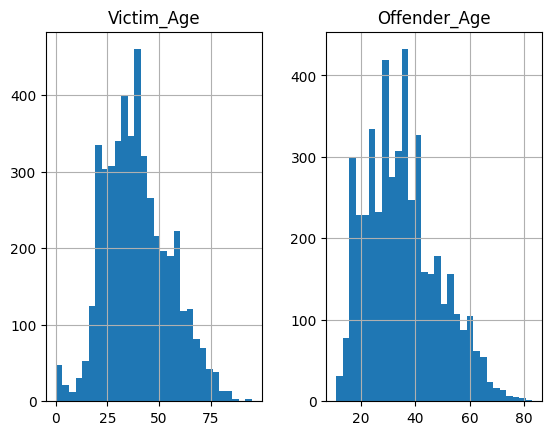

In [17]:
df_clean[["Victim_Age", "Offender_Age"]].hist(bins=30)

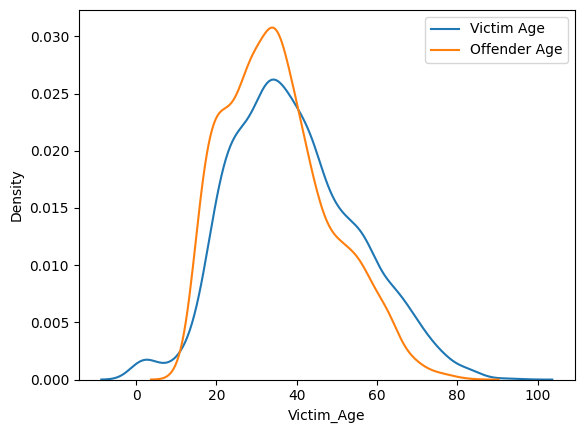

In [18]:
sns.kdeplot(df_clean["Victim_Age"], label="Victim Age")
sns.kdeplot(df_clean["Offender_Age"], label="Offender Age")
plt.legend()

Insight:

- Both distributions are slightly right-skewed
- Most observations are concentrated between 20–40 years
- Offenders and victims tend to fall within similar age ranges

# Victim vs Offender Relationship

<Axes: xlabel='Offender_Age', ylabel='Victim_Age'>

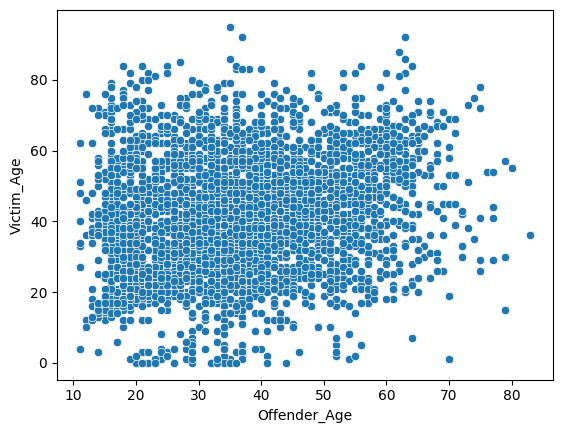

In [19]:
sns.scatterplot(data=df_clean, x="Offender_Age", y="Victim_Age")

Insight:

- No strong linear relationship between victim and offender ages
- Crimes occur across varied age combinations

## Category Analysis

In [20]:
pd.crosstab(df_clean["Category"], df_clean["OffenderStatus"]) , pd.crosstab(df_clean["Category"], df_clean["Victim_Fatal_Status"])

(OffenderStatus          ARRESTED
 Category                        
 DRUG AND WEAPON CRIMES        12
 MISCELLANEOUS                965
 SEXUAL CRIMES                  1
 THEFT                       1005
 VANDALISM                    317
 VIOLENCE                    2393,
 Victim_Fatal_Status     FATAL  NON-FATAL
 Category                                
 DRUG AND WEAPON CRIMES      0         12
 MISCELLANEOUS               6        959
 SEXUAL CRIMES               0          1
 THEFT                       0       1005
 VANDALISM                   0        317
 VIOLENCE                   10       2383)

Insight:

- Violence is the most frequent category
- Followed by Theft and Miscellaneous

## Fatal vs Non-Fatal Analysis

In [21]:
pd.crosstab(df_clean["Category"], df_clean["Victim_Fatal_Status"])

Victim_Fatal_Status,FATAL,NON-FATAL
Category,,
DRUG AND WEAPON CRIMES,0,12
MISCELLANEOUS,6,959
SEXUAL CRIMES,0,1
THEFT,0,1005
VANDALISM,0,317
VIOLENCE,10,2383


Insight:

- Most crimes are non-fatal
- Fatal cases are extremely rare
- Violence accounts for most fatal incidents

## Gender Patterns

In [22]:
df_clean.groupby("Category")["Offender_Gender"].value_counts()

Category                Offender_Gender
DRUG AND WEAPON CRIMES  MALE                 12
MISCELLANEOUS           MALE                668
                        FEMALE              297
SEXUAL CRIMES           FEMALE                1
THEFT                   MALE                815
                        FEMALE              190
VANDALISM               MALE                201
                        FEMALE              116
VIOLENCE                MALE               1694
                        FEMALE              699
Name: count, dtype: int64

Insight:

- Male offenders dominate across all categories
- Indicates a strong gender imbalance in crime participation

## Race Interaction

In [23]:
df_clean.groupby("Offender_Race")["Victim_Race"].value_counts()

Offender_Race                              Victim_Race                              
AMER. IND.                                 BLACK                                           2
                                           AMER. IND.                                      1
                                           WHITE                                           1
ASIAN                                      ASIAN                                           8
                                           BLACK                                           4
                                           WHITE                                           2
BLACK                                      BLACK                                        2782
                                           WHITE                                         859
                                           UNKNOWN                                       110
                                           ASIAN                              

Insight:

- Patterns suggest interactions often occur within similar demographic groups
- Could reflect geographic or social clustering

## Age Gap Distribution by Category

In [24]:
df_clean.groupby("Category")["age_gap"].mean()

Category
DRUG AND WEAPON CRIMES   -5.333333
MISCELLANEOUS             4.462176
SEXUAL CRIMES             5.000000
THEFT                     8.914428
VANDALISM                 6.511041
VIOLENCE                  1.259507
Name: age_gap, dtype: float64

Insight:

- Some categories show wider variability in age differences
- Indicates different behavioral dynamics depending on crime type

## Conclusion

The analysis shows that crime patterns are primarily driven by categorical variables such as type of crime, gender, and demographic characteristics rather than numerical variables like age alone.

Violence is the dominant category, and most incidents are non-fatal. The data also highlights a strong predominance of male offenders and shows that individuals across different age groups are involved in criminal activity.

Additionally, the lack of strong correlations between numerical variables suggests that predictive models would require careful feature engineering, focusing more on categorical variables rather than relying solely on numerical relationships.

Finally, the data cleaning process was critical, as nearly 30% of the dataset consisted of duplicate records, which could have significantly biased the analysis if not addressed.